# 이탈 고위험군 세그먼트 분석

SHAP 상위 변수 기준으로 이탈 고위험군을 정의하고 프로파일링

- **SHAP 1위**: `duration_days` (구독 기간)
- **SHAP 2위**: `price` (결제 금액)
- **SHAP 4위**: `recency` (마지막 시청 ~ 종료일)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('..').resolve()
df = pd.read_csv(
    BASE / 'data/02_interim/260506_feature_engineering/promotion_0_membership_v4.csv',
    encoding='utf-8-sig'
)
df['is_churn'] = 1 - df['is_repurchase']
print(f'shape: {df.shape}')
print(f'이탈률: {df["is_churn"].mean()*100:.1f}%')

shape: (7323, 50)
이탈률: 30.2%


## 1. SHAP 핵심 변수별 이탈률 분포

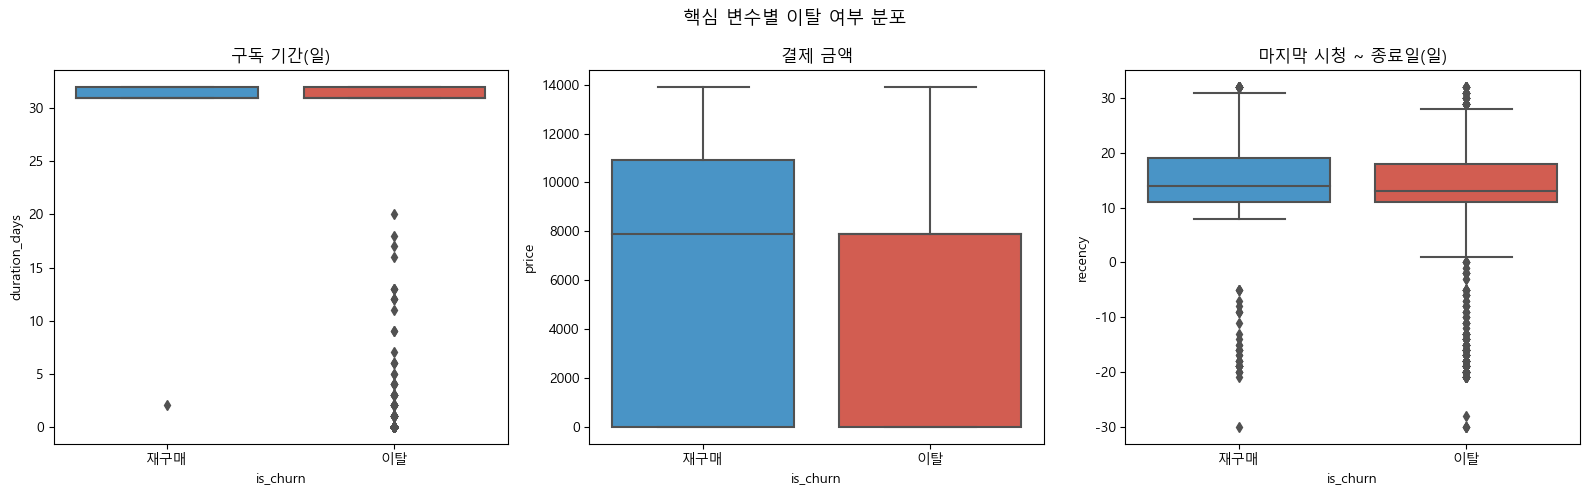

          duration_days    price  recency
is_churn                                 
0                 31.30  6532.12    15.81
1                 27.19  5104.34    12.06


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('핵심 변수별 이탈 여부 분포', fontsize=13)

# duration_days
sns.boxplot(data=df, x='is_churn', y='duration_days', ax=axes[0],
            palette=['#3498db','#e74c3c'])
axes[0].set_xticklabels(['재구매','이탈'])
axes[0].set_title('구독 기간(일)')

# price
sns.boxplot(data=df, x='is_churn', y='price', ax=axes[1],
            palette=['#3498db','#e74c3c'])
axes[1].set_xticklabels(['재구매','이탈'])
axes[1].set_title('결제 금액')

# recency
sns.boxplot(data=df, x='is_churn', y='recency', ax=axes[2],
            palette=['#3498db','#e74c3c'])
axes[2].set_xticklabels(['재구매','이탈'])
axes[2].set_title('마지막 시청 ~ 종료일(일)')

plt.tight_layout()
plt.show()

# 평균 비교
print(df.groupby('is_churn')[['duration_days','price','recency']].mean().round(2))

## 2. 이탈 고위험군 세그먼트 정의

In [3]:
# 이탈률 기준 분위수 확인
print('=== duration_days 분위수 ===')
print(df.groupby('is_churn')['duration_days'].describe().round(1))
print()
print('=== price 분위수 ===')
print(df.groupby('is_churn')['price'].describe().round(1))

=== duration_days 분위수 ===
           count  mean   std  min   25%   50%   75%   max
is_churn                                                 
0         5110.0  31.3   0.6  2.0  31.0  31.0  32.0  32.0
1         2213.0  27.2  10.6  0.0  31.0  31.0  32.0  32.0

=== price 분위수 ===
           count    mean     std  min   25%     50%      75%      max
is_churn                                                             
0         5110.0  6532.1  4694.1  9.9  13.5  7900.0  10900.0  13900.0
1         2213.0  5104.3  4642.0  9.9  10.0  7900.0   7900.0  13900.0


In [4]:
# 세그먼트 정의
df['segment'] = '일반'

# 고위험군: 단기 구독 (31일 미만)
df.loc[df['duration_days'] < 31, 'segment'] = '단기구독'

# 고위험군: 단기 + 저가 (9.99달러 등)
df.loc[(df['duration_days'] < 31) & (df['price'] < 100), 'segment'] = '단기+달러'

# 충성 가능성: 장기 구독 + 최근 시청
df.loc[(df['duration_days'] >= 31) & (df['recency'] <= 5), 'segment'] = '장기+활성'

print('세그먼트별 분포:')
seg_stats = df.groupby('segment').agg(
    유저수=('is_churn','count'),
    이탈률=('is_churn','mean'),
    평균구독일=('duration_days','mean'),
    평균가격=('price','mean'),
).round(3)
seg_stats['이탈률'] = (seg_stats['이탈률'] * 100).round(1).astype(str) + '%'
print(seg_stats)

세그먼트별 분포:
          유저수     이탈률   평균구독일      평균가격
segment                                
단기+달러     112  100.0%   0.241    11.580
단기구독      197   99.5%   1.431  8932.487
일반       6948   27.0%  31.338  6103.137
장기+활성      66   40.9%  31.303  7719.118


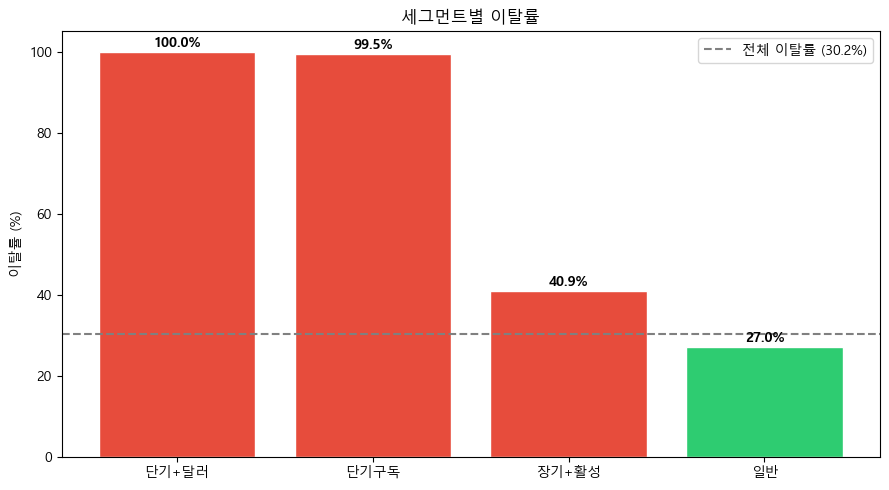

In [5]:
# 세그먼트별 이탈률 시각화
seg_churn = df.groupby('segment')['is_churn'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0.4 else '#f39c12' if v > 0.3 else '#2ecc71'
          for v in seg_churn.values]
bars = ax.bar(seg_churn.index, seg_churn.values * 100, color=colors, edgecolor='white')
ax.axhline(df['is_churn'].mean()*100, linestyle='--', color='gray', label=f'전체 이탈률 ({df["is_churn"].mean()*100:.1f}%)')
ax.set_ylabel('이탈률 (%)')
ax.set_title('세그먼트별 이탈률')
ax.legend()
for bar, val in zip(bars, seg_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. 이탈 고위험군 프로파일

In [6]:
# 이탈 vs 재구매 유저 특성 비교
profile_cols = [
    'duration_days','price','recency','completion_rate',
    'avg_rewatch_ratio','watch_per_day','signup_to_first_watch',
    'retention_w2_ratio','retention_w3_ratio','age'
]
profile_cols = [c for c in profile_cols if c in df.columns]

profile = df.groupby('is_churn')[profile_cols].mean().T
profile.columns = ['재구매','이탈']
profile['차이(이탈-재구매)'] = profile['이탈'] - profile['재구매']
profile['비율(이탈/재구매)'] = (profile['이탈'] / profile['재구매'].replace(0, np.nan)).round(2)

print('=== 이탈 vs 재구매 유저 프로파일 ===')
print(profile.round(3).to_string())

=== 이탈 vs 재구매 유저 프로파일 ===
                                재구매            이탈   차이(이탈-재구매)  비율(이탈/재구매)
duration_days          3.129700e+01  2.719400e+01       -4.103        0.87
price                  6.532122e+03  5.104343e+03    -1427.778        0.78
recency                1.581500e+01  1.205800e+01       -3.757        0.76
completion_rate        3.940000e-01  3.910000e-01       -0.003        0.99
avg_rewatch_ratio      2.230000e-01  2.380000e-01        0.015        1.07
watch_per_day          1.794000e+00  1.874000e+00        0.079        1.04
signup_to_first_watch  5.326000e+00  5.340000e+00        0.015        1.00
retention_w2_ratio     2.646478e+07  2.881835e+07  2353571.637        1.09
retention_w3_ratio     3.068826e+07  3.413557e+07  3447306.491        1.11
age                    3.575400e+01  3.504100e+01       -0.714        0.98


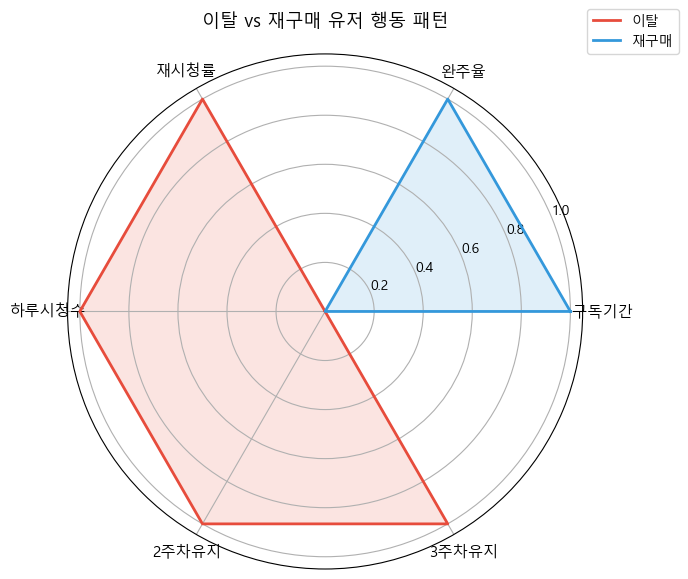

In [7]:
# 프로파일 레이더 차트
from matplotlib.patches import FancyArrowPatch

# 주요 변수 정규화 비교
radar_cols = ['duration_days','completion_rate','avg_rewatch_ratio',
              'watch_per_day','retention_w2_ratio','retention_w3_ratio']
radar_cols = [c for c in radar_cols if c in df.columns]

churn_mean    = df[df['is_churn']==1][radar_cols].mean()
repurchase_mean = df[df['is_churn']==0][radar_cols].mean()

# 0~1 정규화
combined = pd.DataFrame([churn_mean, repurchase_mean])
norm = (combined - combined.min()) / (combined.max() - combined.min() + 1e-9)

labels = ['구독기간','완주율','재시청률','하루시청수','2주차유지','3주차유지']
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (label, color) in enumerate([('이탈', '#e74c3c'), ('재구매', '#3498db')]):
    vals = norm.iloc[i].tolist() + norm.iloc[i].tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('이탈 vs 재구매 유저 행동 패턴', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()